In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('train_labeled.csv')

# Mapping label
label_map = {
    0: 'Negative',
    1: 'Neutral',
    2: 'Positive'
}


In [2]:
# Konversi label numerik ke teks
df['sentiment'] = df['label'].map(label_map)

# Total data
total = len(df)

C:\Users\Sidqi\AppData\Local\Temp\ipykernel_29456\2957349174.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


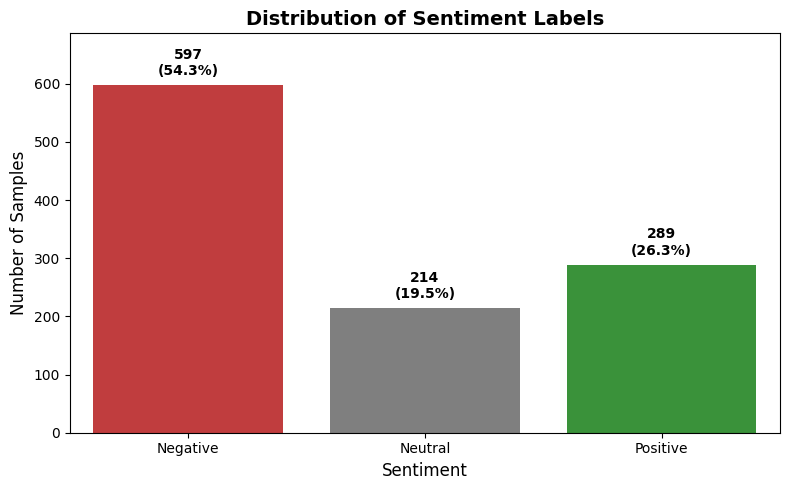

In [5]:
# Warna tiap kelas
colors = ['#d62728', '#7f7f7f', '#2ca02c']  # merah, abu, hijau

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x='sentiment',
    order=['Negative', 'Neutral', 'Positive'],
    palette=colors
)

# Cari nilai maksimum untuk menentukan jarak teks
max_count = df['sentiment'].value_counts().max()

# Tambahkan label jumlah dan persentase
for p in ax.patches:
    count = int(p.get_height())
    percentage = count / total * 100

    ax.annotate(
        f'{count}\n({percentage:.1f}%)',
        (p.get_x() + p.get_width()/2, count + max_count*0.02),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Distribution of Sentiment Labels', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)

# Kasih ruang di atas supaya teks tidak kepotong
plt.ylim(0, max_count * 1.15)

plt.tight_layout()
plt.show()

In [4]:
# Tampilkan ringkasan distribusi
print("\nLabel Distribution:")
print(df['sentiment'].value_counts())

print("\nLabel Distribution (%):")
print(round(df['sentiment'].value_counts(normalize=True) * 100, 2))


Label Distribution:
sentiment
Negative    597
Positive    289
Neutral     214
Name: count, dtype: int64

Label Distribution (%):
sentiment
Negative    54.27
Positive    26.27
Neutral     19.45
Name: proportion, dtype: float64
